In [37]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [38]:
df_US = df[df['job_country'] == 'United States']
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Created new data frame where I want to filter specific country i.e "United States" data only 

In [39]:
df_skills = df_US.explode('job_skills')

Used explode method to broke out skills that existed as a multiple skills in list

In [40]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

#Doing it, it converts series to dataframe format so that it will be easy to manipulate data or in this case count data
df_skills_count = df_skills_count.reset_index(name = 'skill_count')

#Sorting the values of skill_count column in descending order
df_skills_count.sort_values(by= 'skill_count', ascending = False, inplace = True)

#Now we need to get the top 3 roles we can directly define it 
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']



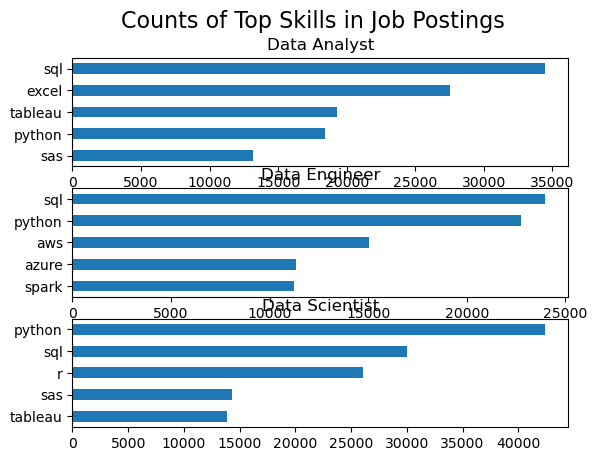

In [41]:
# Plotting it 
# Three seperate plots for 3 diff roles 
fig, ax = plt.subplots(len(job_titles),1)
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5) #skills counts top 5 skills only based on job title short column above
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    #sns.barplot(data=df_plot, x='skill_percent', y='job skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize = 16)
plt.show()

In [45]:
#Calculating percentage of skill per job postings ie [% of skill in a job posting = skill count in jobpostings) / (total count of job postings)]
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total') #resetting index to convert series to DF job_total is the name of total job counts/job_totals


In [43]:
#Now merging tables df_job_title_count with df_skills_count using pandas merge func
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how = 'left', on='job_title_short')
#as we are doing focusing skill count/ skill percentage per job title short we care about skill data more so empty data of job title we dont want that thats why we use left join

#Final part of calculating percentage skill count / total count of job postings
df_skills_perc['skill_percent']= 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']
df_skills_perc
# Lets plot this now

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,vue.js,Business Analyst,1,7382,0.013546
1866,arch,Business Analyst,1,7382,0.013546
1867,asana,Machine Learning Engineer,1,921,0.108578
1868,no-sql,Machine Learning Engineer,1,921,0.108578


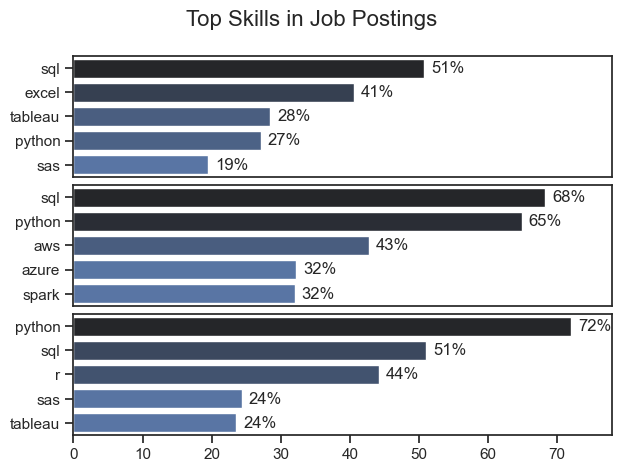

In [67]:
# Plotting percentage
# Three seperate plots for 3 diff roles 
fig, ax = plt.subplots(len(job_titles),1)

#theme color 
sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short']==job_title].head(5) #skills counts top 5 skills only based on job title short column above
    #df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=job_title)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    ax[i].legend().set_visible(False)

    # displaying percent in each bar using loop / cycling through the index 'n' and value 'v'
    for n, v in enumerate(df_plot['skill_percent']):#we want the index thats why we have to do enumerate
        #using the actual axis instead of plt.text() itself
        ax[i].text(v+1, n, f'{v:.0f}%', va = 'center') #10:21:00

    if i != len(job_titles) -1:
        ax[i].set_xticks([])        

fig.suptitle('Top Skills in Job Postings', fontsize = 16)
fig.tight_layout(h_pad = 0.5) #to fix the overlap
plt.show()